# Standby detection, first iteration

Simple check of ten electricity meters. Each file holds one reading per 15 minutes: timestamp plus kWh used in that slot.

This notebook answers the five brief tasks: (1) a basic rule, (2) per-meter hours and energy, (3) why this rule, (4) where it misleads and what stays off a customer screen, (5) next steps plus what extra info I would want.

How to run: open this notebook and choose Restart & Run All. It reads `../data/raw/meter_*.csv` and writes `../outputs/meter_summary.csv` and `../outputs/thresholds.csv`. The same rule also runs from the command line for a new file: `python main.py --input path/to/new.csv --output outputs/unseen`.

In [16]:
%matplotlib inline
import sys
sys.path.insert(0, "..")
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from main import load, fit, run, summarise, QUIET_HOURS

DATA = Path("../data/raw")
OUT = Path("../outputs")
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "plots").mkdir(exist_ok=True)
df = load(DATA)
print(f"{len(df):,} rows across {df['meter_id'].nunique()} meters")

239,699 rows across 10 meters


## 1. The data

Ten files, one per meter. Coverage differs per meter, so every total below is for the period that meter actually covers. No yearly scaling.

In [17]:
rows = []
for mid, g in df.groupby("meter_id"):
    rows.append({
        "meter": mid,
        "period": f"{g['timestamp'].iloc[0][:10]} to {g['timestamp'].iloc[-1][:10]}",
        "rows": len(g),
        "missing": int(g["is_missing"].sum()),
        "zeros": int(((~g["is_missing"]) & (g["value_kwh"] == 0)).sum()),
    })
cover = pd.DataFrame(rows).sort_values("meter")
cover

,meter,period,rows,missing,zeros
0,meter_1,2025-12-01 to 2026-09-01,26300,0,15889
1,meter_10,2025-12-01 to 2026-09-01,26300,29,1097
2,meter_2,2025-12-01 to 2026-08-28,25975,0,7086
3,meter_3,2025-12-01 to 2026-08-28,25975,0,111
4,meter_4,2026-07-03 to 2026-09-01,5713,495,243
5,meter_5,2025-12-01 to 2026-09-01,26300,1947,0
6,meter_6,2025-12-01 to 2026-09-01,26300,0,5301
7,meter_7,2025-12-22 to 2026-09-01,24236,51,2349
8,meter_8,2025-12-01 to 2026-09-01,26300,0,15
9,meter_9,2025-12-01 to 2026-09-01,26300,32,16437


## 2. What I checked before the rule

- Missing stays missing. An empty cell never becomes zero. Gaps show as unknown. Filling them would invent use I never saw. Meter 5 is empty for 17 days over Christmas: writing those as zero would create 400+ hours of fake zero use.
- Zeros stay apart from low use. Meter 2 is zero for 73 days straight to the end of its file. That looks like a shutdown, not a machine left on at night. Meter 6 has many short zero spells, which looks like normal on-off cycling. Mixing the two would call a dead meter my best saving.
- One limit for all meters cannot work. Typical use differs by a factor of about 900 between the smallest and largest meter. A fixed limit would never trigger on the small ones and always trigger on the large one. So each meter gets its own limit from its own data.
- Time: I sort by UTC (clean clock) and read night/weekend from local time (what people mean by night).

quality check: 0 duplicate timestamps; 0 non-15-minute UTC gaps; 9 meters cross a clock change
scale span: 898x between smallest and largest median


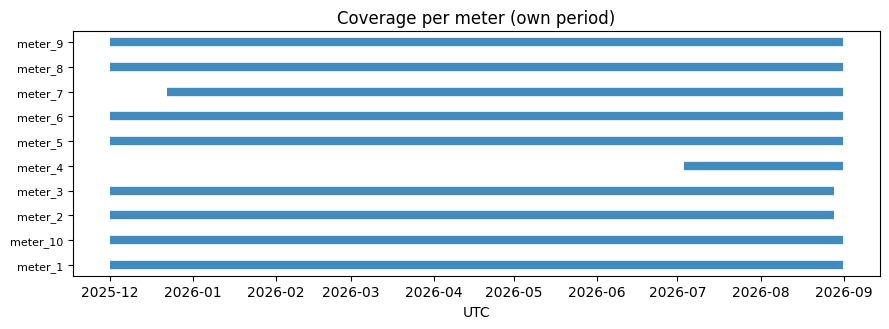

In [18]:
# Basic quality check before the rule: duplicates and UTC cadence.
quality = []
for mid, g in df.groupby("meter_id"):
    ts = g["ts_utc"].sort_values()
    gaps = ts.diff().dt.total_seconds().div(60).dropna()
    quality.append({
        "meter": mid,
        "duplicate_timestamps": int(g["ts_utc"].duplicated().sum()),
        "non_15_min_utc_gaps": int((gaps != 15).sum()),
        "local_utc_offsets": int(g["ts_local"].map(lambda t: t.utcoffset().total_seconds() / 3600).nunique()),
    })
quality = pd.DataFrame(quality).sort_values("meter")
print(f"quality check: {quality['duplicate_timestamps'].sum()} duplicate timestamps; {quality['non_15_min_utc_gaps'].sum()} non-15-minute UTC gaps; {(quality['local_utc_offsets'] > 1).sum()} meters cross a clock change")
quality

# Coverage chart: proves no meter shares a calendar, so totals are per-period only.
fig, ax = plt.subplots(figsize=(9, 3.4))
for i, mid in enumerate(sorted(df["meter_id"].unique())):
    g = df[df["meter_id"] == mid]
    ax.hlines(i, g["ts_utc"].min().tz_convert(None), g["ts_utc"].max().tz_convert(None), lw=6, alpha=0.85)
ax.set_yticks(range(10))
ax.set_yticklabels(sorted(df["meter_id"].unique()), fontsize=8)
ax.set_xlabel("UTC")
ax.set_title("Coverage per meter (own period)")
fig.tight_layout()
fig.savefig(OUT / "plots" / "coverage.png", dpi=150)
# Scale span: median of positive readings, largest over smallest.
meds = df[(~df["is_missing"]) & (df["value_kwh"] > 0)].groupby("meter_id")["value_kwh"].median()
print(f"scale span: {meds.max() / meds.min():.0f}x between smallest and largest median")
plt.show()

## 3. The rule (simple on purpose)

- Turn kWh per slot into mean power: kWh x 4. Each row is 15 minutes (a quarter hour), so x4 gives kW. Limits read in kW.
- Quiet hours: local night 22:00-05:59, or any weekend hour. Those are the hours work should be off.
- Limit per meter: 4 x the 25th percentile of positive quiet readings. The lower quarter shows the floor without chasing the single lowest outlier. Positive only, because zeros would drag the limit to zero on meters that are often off.
- Dwell: a low reading counts only as part of two low readings in a row. One low slot can be a dip or a bad reading. Real standby lasts longer.
- Decline: fewer than 200 positive quiet readings, or quiet median above half the weekday-day median, means declined. No number at all, not zero. Below 200 is about 50 hours of proof, too thin for a stable limit. Above half means night looks like day, so no quiet floor exists.
- Excess: candidate kWh above a 0 kWh off baseline. It is energy you might save, not proven waste. Zero is the only baseline the files support: no shift plan, no rated power, no run signal.

In [19]:
thr = fit(df)
thr

meter_1 thr=2.356kW ratio=0.385 estimated
meter_10 thr=0.590kW ratio=0.992 declined
meter_2 thr=1.536kW ratio=0.997 declined
meter_3 thr=12.933kW ratio=0.512 declined
meter_4 thr=4.948kW ratio=0.830 declined
meter_5 thr=4.560kW ratio=0.177 estimated
meter_6 thr=145.920kW ratio=0.362 estimated
meter_7 thr=0.574kW ratio=0.036 estimated
meter_8 thr=49.200kW ratio=0.289 estimated
meter_9 thr=1.035kW ratio=0.583 declined


,meter_id,thr_kw,n_quiet_pos,quiet_day_ratio,status,status_reason
0,meter_1,2.356440,1725,0.384774,estimated,ok
2,meter_2,1.536044,9821,0.996830,declined,no_distinct_quiet_regime
3,meter_3,12.933200,13437,0.511514,declined,no_distinct_quiet_regime
4,meter_4,4.947782,2567,0.829982,declined,no_distinct_quiet_regime
5,meter_5,4.560000,12572,0.177447,estimated,ok
6,meter_6,145.920000,11156,0.361755,estimated,ok
7,meter_7,0.574232,11058,0.036064,estimated,ok
8,meter_8,49.200000,13756,0.288633,estimated,ok
9,meter_9,1.035000,4975,0.583090,declined,no_distinct_quiet_regime
1,meter_10,0.590296,13192,0.992033,declined,no_distinct_quiet_regime


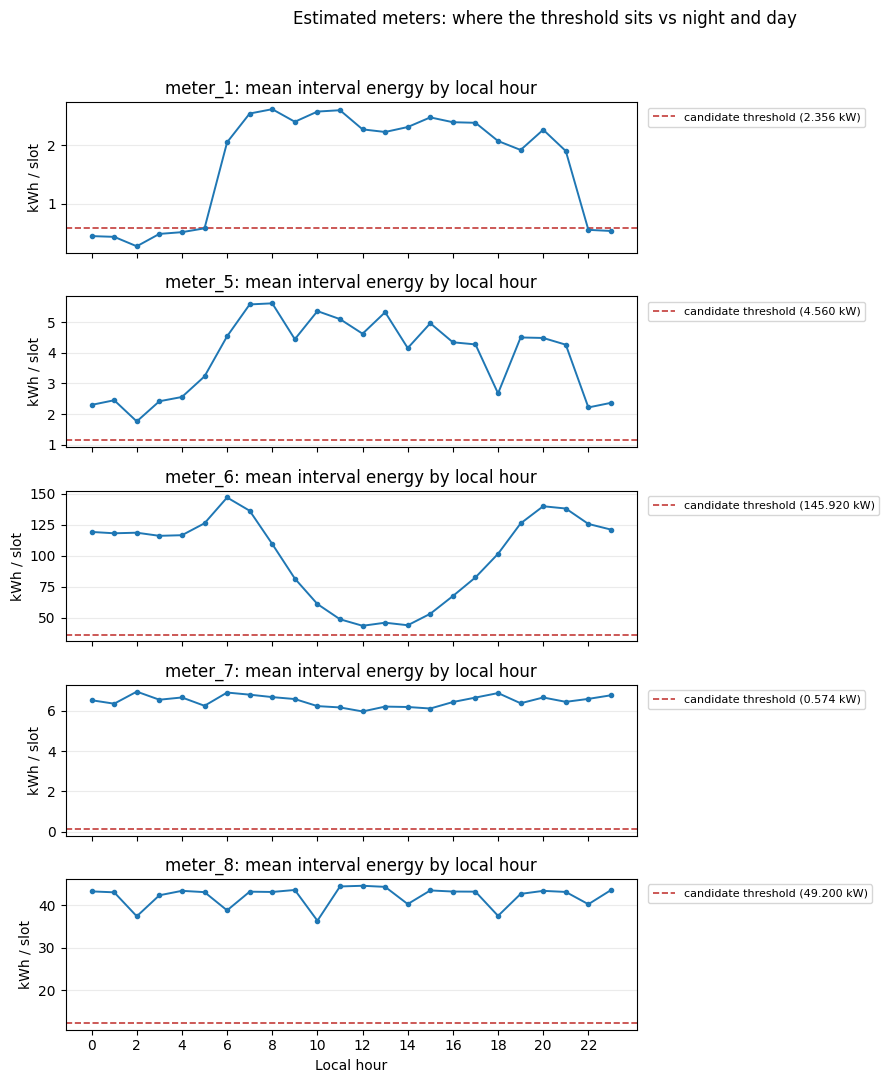

In [20]:
# Estimated meters: the rule set a limit, so we draw it.
# Mean kWh per 15-min slot by local hour (zeros included).
# Red dashed line = candidate threshold (thr_kw / 4).
def hourly_mean_all(mid):
    d = df[(df["meter_id"] == mid) & (~df["is_missing"])].copy()
    d["h"] = [t.hour for t in d["ts_local"]]
    return d.groupby("h")["value_kwh"].mean().reindex(range(24))
est_meters = ["meter_1", "meter_5", "meter_6", "meter_7", "meter_8"]
fig, axes = plt.subplots(5, 1, figsize=(11, 11), sharex=True)
for ax, mid in zip(axes, est_meters):
    h = hourly_mean_all(mid)
    t_kw = float(thr.loc[thr["meter_id"] == mid, "thr_kw"].iloc[0])
    ax.axhline(t_kw / 4.0, color="#c43c39", ls="--", lw=1.2,
               label=f"candidate threshold ({t_kw:.3f} kW)")
    ax.plot(h.index, h.values, marker="o", ms=3, lw=1.4, color="#1f77b4")
    ax.set(title=f"{mid}: mean interval energy by local hour", ylabel="kWh / slot")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
axes[-1].set(xlabel="Local hour", xticks=range(0, 24, 2))
fig.suptitle("Estimated meters: where the threshold sits vs night and day")
fig.tight_layout(rect=[0, 0, 0.82, 0.96])
fig.savefig(OUT / "plots" / "rule_estimated.png", dpi=150)
plt.show()


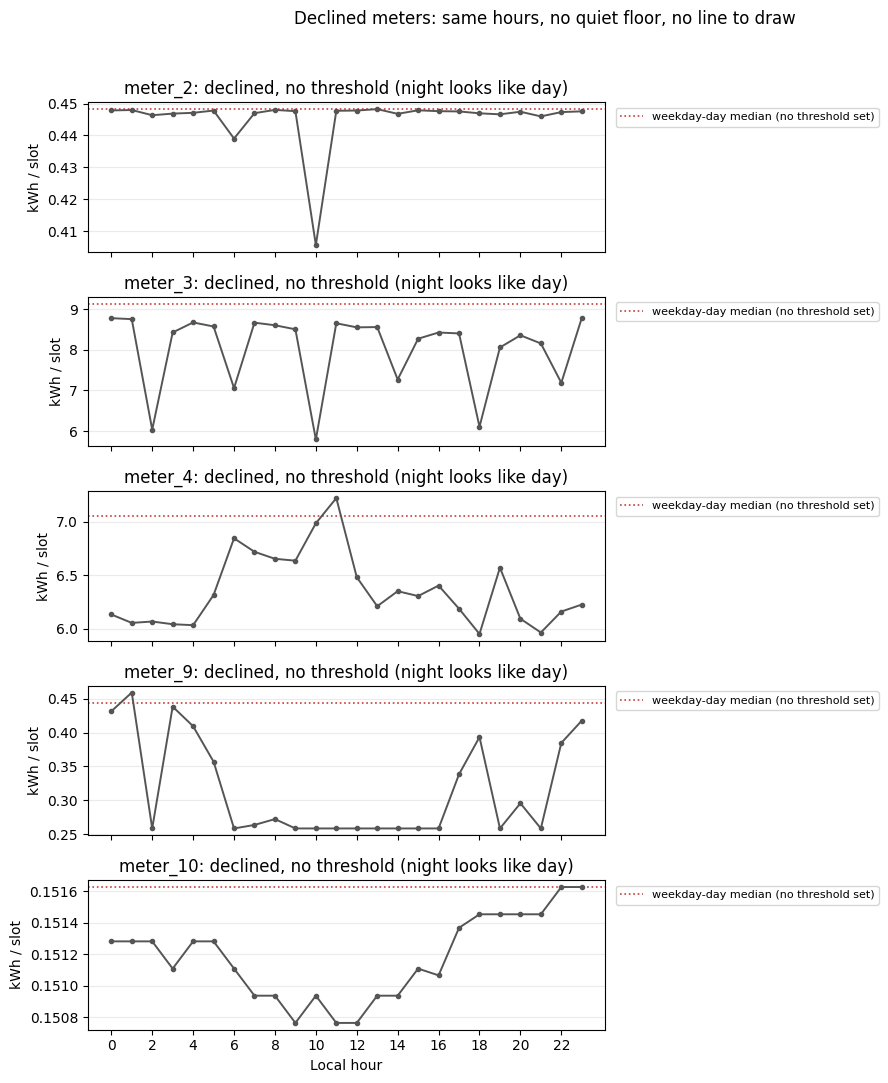

In [21]:
# Declined meters: no limit was set, so none is drawn.
# Hourly MEDIAN + weekday-day MEDIAN, positive readings only.
# Flat meters hug the dotted line: night looks like day.
def hourly_med_pos(mid):
    d = df[(df["meter_id"] == mid) & (~df["is_missing"]) & (df["value_kwh"] > 0)].copy()
    d["h"] = [t.hour for t in d["ts_local"]]
    return d.groupby("h")["value_kwh"].median().reindex(range(24))
dec_meters = ["meter_2", "meter_3", "meter_4", "meter_9", "meter_10"]
fig, axes = plt.subplots(5, 1, figsize=(11, 11), sharex=True)
for ax, mid in zip(axes, dec_meters):
    h = hourly_med_pos(mid)
    d = df[(df["meter_id"] == mid) & (~df["is_missing"]) & (df["value_kwh"] > 0)]
    day_med = float(d.loc[d["is_day"], "value_kwh"].median())
    ax.axhline(day_med, color="#c43c39", ls=":", lw=1.2,
               label="weekday-day median (no threshold set)")
    ax.plot(h.index, h.values, marker="o", ms=3, lw=1.4, color="#555555")
    ax.set(title=f"{mid}: declined, no threshold (night looks like day)",
           ylabel="kWh / slot")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
axes[-1].set(xlabel="Local hour", xticks=range(0, 24, 2))
fig.suptitle("Declined meters: same hours, no quiet floor, no line to draw")
fig.tight_layout(rect=[0, 0, 0.82, 0.96])
fig.savefig(OUT / "plots" / "rule_declined.png", dpi=150)
plt.show()


## 4. Results

Every meter over the period it actually covers. Declined means the data never showed a clear quiet pattern. Excess is candidate kWh above a 0 kWh baseline.

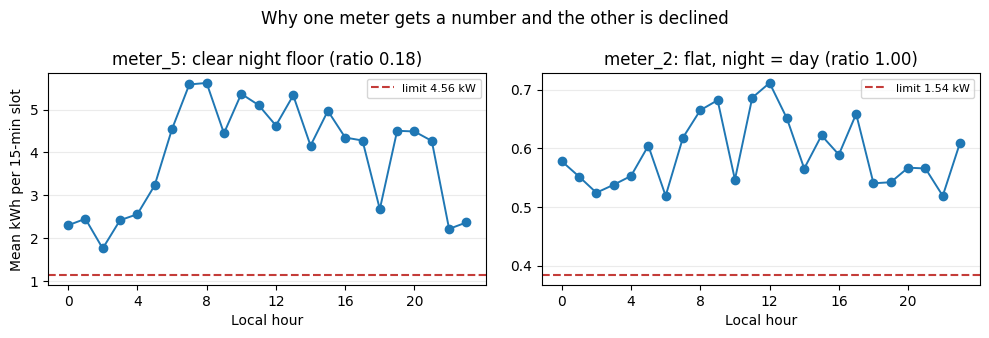

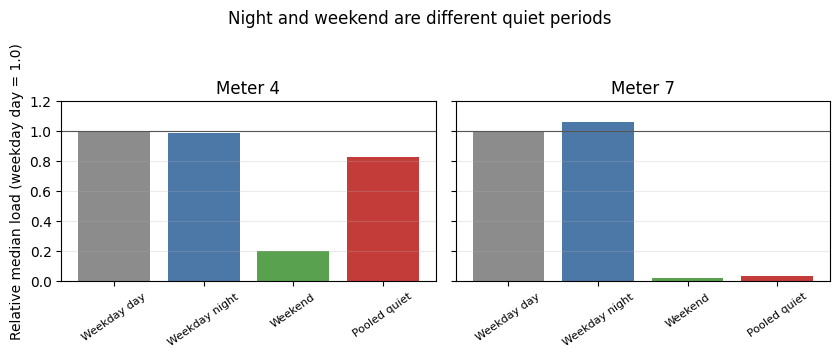

In [22]:
det = run(df, thr)
summ = summarise(df, det, thr)
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "plots").mkdir(exist_ok=True)
thr.to_csv(OUT / "thresholds.csv", index=False)
summ.to_csv(OUT / "meter_summary.csv", index=False)
summ
# Contrast chart: one meter with a clear floor vs one flat meter.
from datetime import datetime as _dt
def hourly(mid):
    d = df[df["meter_id"] == mid].copy()
    d = d[(~d["is_missing"]) & (d["value_kwh"] > 0)]
    d["h"] = [t.hour for t in d["ts_local"]]
    return d.groupby("h")["value_kwh"].mean().reindex(range(24))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, mid, title in zip(axes,
    ["meter_5", "meter_2"],
    ["meter_5: clear night floor (ratio 0.18)", "meter_2: flat, night = day (ratio 1.00)"]):
    h = hourly(mid)
    t = float(thr.loc[thr["meter_id"] == mid, "thr_kw"].iloc[0]) * 0.25
    ax.plot(h.index, h.values, marker="o", lw=1.4)
    ax.axhline(t, color="#c43c39", ls="--", label=f"limit {t * 4:.2f} kW")
    ax.set(title=title, xlabel="Local hour", xticks=range(0, 24, 4))
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Mean kWh per 15-min slot")
fig.suptitle("Why one meter gets a number and the other is declined")
fig.tight_layout()
fig.savefig(OUT / "plots" / "quiet_contrast.png", dpi=150)
plt.show()

# Night/weekend split: show why one pooled quiet window can mislead.
def regime_ratios(mid):
    d = df[(df["meter_id"] == mid) & (~df["is_missing"]) & (df["value_kwh"] > 0)]
    day = d.loc[d["is_day"], "value_kwh"].median()
    night = d.loc[(d["weekday"] < 5) & d["hour"].isin(QUIET_HOURS), "value_kwh"].median()
    weekend = d.loc[d["weekday"] >= 5, "value_kwh"].median()
    quiet = d.loc[d["is_quiet"], "value_kwh"].median()
    return [1.0, night / day, weekend / day, quiet / day]

labels = ["Weekday day", "Weekday night", "Weekend", "Pooled quiet"]
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.6), sharey=True)
for ax, mid in zip(axes, ["meter_4", "meter_7"]):
    ax.bar(labels, regime_ratios(mid), color=["#8c8c8c", "#4c78a8", "#59a14f", "#c43c39"])
    ax.axhline(1, color="#555", lw=0.8)
    ax.set_title(mid.replace("meter_", "Meter "))
    ax.set_ylim(0, 1.2)
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Relative median load (weekday day = 1.0)")
fig.suptitle("Night and weekend are different quiet periods")
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(OUT / "plots" / "night_weekend_split.png", dpi=150)
plt.show()

## 5. Critique, next steps, wanted info

What I would not show a paying customer:

- Meters 6 and 8 pass the test but their limits (146 kW, 49 kW) look like plant running, not a small machine left on. On hold until I know the machine.
- Any number for the five declined meters (2, 3, 4, 9, 10). Declined means no clear quiet floor. Publishing zero would sound exact while hiding "we do not know".
- A yearly total for meter 4. Two summer months with an 8% gap cannot speak for a year.
- A claim that meter 5 shows waste. It is the strongest lead (1,141 hours, no zeros), but the floor could be required cooling or IT. Without a schedule it is "worth a visit", not "waste".
- A claim that zero means the machine was off. Zero proves zero measured energy, not which machine stopped.

One line per meter: 1 is mostly off (3,972 zero hours matter more than 197 candidate hours). 2 is flat, night = day. 3 sits on the edge at 0.51, so declined. 4 has busy nights but quiet weekends, pooled together they hide the weekend. 5 is the clearest lead. 6 and 8 are plant size, on hold. 7 has the sharpest split plus one 288 kWh spike kept in the totals and flagged. 9 is mostly off with no clear pattern. 10 is flat near 0.15 kWh all day.

Next: split night and weekend into two cases; link meter to machine, rated power, and work calendar so standby means "on while the plan says off"; add separate on/off limits so noisy data does not flip the result; flag spikes per meter and keep them in totals until confirmed; for live use store raw as-is, use meter plus time as key, mark early vs final rows, and re-run only the changed window.

What I still need and why: which meter feeds which machine and site (else standby is a math floor, not proof); rated power and always-on loads like IT/heating (to tell base load from waste); shift plan, holidays, stops (to keep Christmas out of quiet hours); whether each timestamp starts or ends its slot (moves night borders by 15 min); how late the provider sends fixes and when data is final (so late fixes do not rewrite totals silently).

In [23]:
# New-meter test: a renamed copy of meter_7 must give the same limit with no code change.
import shutil, tempfile
tmp = Path(tempfile.mkdtemp())
shutil.copy(DATA / "meter_7.csv", tmp / "meter_new.csv")
df2 = load(tmp / "meter_new.csv")
thr2 = fit(df2)
det2 = run(df2, thr2)
summ2 = summarise(df2, det2, thr2)
summ2[["meter_id", "thr_kw", "standby_candidate_hours", "excess_kwh", "status"]]

meter_new thr=0.574kW ratio=0.036 estimated


,meter_id,thr_kw,standby_candidate_hours,excess_kwh,status
0,meter_new,0.574,700.25,148.525316,estimated
